# EfficientSAM → Core ML (segment everything on device)

Exports EfficientSAM as a **split encoder / decoder** `.mlpackage` pair sized for
mobile, then validates the exported models against PyTorch and runs a full
`GRID_SIZE = 32` segment-everything pass under a bounded memory budget.

The split is the whole point. Measured on CPU for VIT-tiny:

| stage | cost |
|---|---|
| encoder | 0.85 s, **once per image** |
| decoder | ~27 ms **per point** |

`EfficientSAM_segment_everything_example.ipynb` re-runs the encoder for every
batch and decodes masks at full image resolution. On a 1072x603 image a
32x32 grid means `1024 * 3 * 603 * 1072 * 4 B` ~= **7.9 GB** of mask logits in
one tensor, which kills the kernel.

Three changes fix it, and none of them reduce the grid:

1. **Encoder runs once.** Cache the `(1, 256, 64, 64)` embedding, feed it to every
   decoder call.
2. **Decode at low resolution.** `256x256` logits, upsample only the masks that
   survive filtering.
3. **Batch the prompts.** Peak memory is `batch_size * 3 * out_h * out_w` and has
   nothing to do with `GRID_SIZE` — 1024 points at batch 8 peaks exactly like 64
   points at batch 8, just with more iterations.

Filtering and RLE-encoding happen *inside* the batch loop, so the accumulator
never holds full-resolution masks either.

## Setup

In [1]:
import os, sys, gc, time, resource

# Run from the repo root so "weights/" and "figs/" resolve.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print(os.getcwd())

/Users/nuhash/Desktop/other-codes/EfficientSAM


In [2]:
try:
    import coremltools
except ImportError:
    !pip install coremltools

TensorFlow version 2.15.0 has not been tested with coremltools. You may run into unexpected errors. TensorFlow 2.12.0 is the most recent version that has been tested.


In [3]:
import numpy as np
import torch
import torch.nn.functional as F
import coremltools as ct
from PIL import Image
from torchvision.transforms import ToTensor

print("torch     ", torch.__version__)
print("coremltools", ct.__version__)

torch      2.4.1
coremltools 8.3.0


## Export configuration

Core ML wants fixed input shapes to schedule work on the Neural Engine, so both
models are exported with static shapes.

`ENCODER_SIZE = 1024` matches the ViT's native `img_size`; images are letterboxed
to it at inference. `DECODER_BATCH` fixes how many point prompts the decoder
takes per call — it is the single knob controlling peak memory.

`OUTPUT_SIZE = 256` is the resolution the decoder emits logits at. Survivors get
upsampled to full resolution later; everything filtered out never costs
full-resolution memory.

In [4]:
MODEL_NAME     = "vitt"   # "vitt" (10M params) or "vits" (26M) — vitt for mobile
ENCODER_SIZE   = 1024     # ViT native img_size; encoder input is ENCODER_SIZE^2
DECODER_BATCH  = 8        # point prompts per decoder call — the memory knob
OUTPUT_SIZE    = 256      # decoder logit resolution (upsample survivors only)
COMPUTE_UNITS  = ct.ComputeUnit.ALL   # ALL = ANE + GPU + CPU
QUANTIZE       = True     # fp16 weights (~2x smaller, ANE-native)

OUT_DIR = "weights/coreml"
os.makedirs(OUT_DIR, exist_ok=True)

ENCODER_PATH = f"{OUT_DIR}/efficient_sam_{MODEL_NAME}_encoder.mlpackage"
DECODER_PATH = f"{OUT_DIR}/efficient_sam_{MODEL_NAME}_decoder.mlpackage"
print(ENCODER_PATH)
print(DECODER_PATH)

weights/coreml/efficient_sam_vitt_encoder.mlpackage
weights/coreml/efficient_sam_vitt_decoder.mlpackage


## Load the PyTorch model

In [5]:
import zipfile

if MODEL_NAME == "vitt":
    from efficient_sam.build_efficient_sam import build_efficient_sam_vitt as build_fn
else:
    from efficient_sam.build_efficient_sam import build_efficient_sam_vits as build_fn
    # VIT-small checkpoint ships zipped because it is >100MB.
    if not os.path.exists("weights/efficient_sam_vits.pt"):
        with zipfile.ZipFile("weights/efficient_sam_vits.pt.zip") as z:
            z.extractall("weights")

pt_model = build_fn().eval()
n_params = sum(p.numel() for p in pt_model.parameters())
print(f"{MODEL_NAME}: {n_params/1e6:.1f}M params")

vitt: 10.2M params


/Users/nuhash/Desktop/other-codes/EfficientSAM/efficient_sam/efficient_sam.py:303: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f, map_location="cpu

## Traceable wrappers

`efficient_sam.py` is not directly traceable for Core ML — the forward pass does
letterbox preprocessing and dynamic-shape interpolation that would bake bad
constants into the graph. These two wrappers expose exactly the tensor-in /
tensor-out contract each stage needs.

The encoder takes an already-resized `1024x1024` image. The decoder takes the
cached embedding plus a **fixed** `DECODER_BATCH` of prompts, and emits logits at
`OUTPUT_SIZE`.

The decoder pads or truncates prompts to `decoder_max_num_input_points` exactly
as `onnx_models.py` does — that padding convention is what the prompt encoder
expects, and getting it wrong silently produces garbage masks.

### Why the encoder forward is reimplemented

`ImageEncoderViT.forward` calls `get_abs_pos`, which **bicubically** resizes the
positional embedding. Core ML has no `upsample_bicubic2d` op, so tracing the
stock forward fails outright:

```
RuntimeError: PyTorch convert function for op 'upsample_bicubic2d' not implemented.
```

The resize is unavoidable — `pos_embed` is stored at the pretrain resolution of
224 (a `14x14` patch grid, shape `(1, 197, 192)`) while a 1024 input needs
`64x64`. But it depends only on a frozen parameter, so the result is a
**constant**. Computing it once in `__init__` and registering it as a buffer
removes the op from the graph entirely, with zero numerical difference. The rest
of the forward is copied verbatim from `efficient_sam_encoder.py`.

In [6]:
from efficient_sam.efficient_sam_encoder import get_abs_pos


class CoreMLEncoder(torch.nn.Module):
    """Image -> cached embedding. Runs once per image.

    Reimplements ImageEncoderViT.forward with the positional embedding
    pre-resolved, so no bicubic interpolation reaches the Core ML graph.
    """

    def __init__(self, model):
        super().__init__()
        self.encoder = model.image_encoder
        grid = self.encoder.img_size // self.encoder.patch_embed.proj.kernel_size[0]
        with torch.no_grad():
            abs_pos = get_abs_pos(
                self.encoder.pos_embed,
                self.encoder.pretrain_use_cls_token,
                [grid, grid],
            )
        # Constant w.r.t. the input: fold it in instead of recomputing per call.
        self.register_buffer("abs_pos", abs_pos)
        self.grid = grid

    def forward(self, image):
        # image: (1, 3, ENCODER_SIZE, ENCODER_SIZE), already normalized to [0,1]
        x = self.encoder.patch_embed(image)
        x = x.permute(0, 2, 3, 1)          # B C H W -> B H W C
        x = x + self.abs_pos
        n = self.grid
        x = x.reshape(x.shape[0], n * n, x.shape[3])
        for blk in self.encoder.blocks:
            x = blk(x)
        x = x.reshape(x.shape[0], n, n, x.shape[2])
        return self.encoder.neck(x.permute(0, 3, 1, 2))


class CoreMLDecoder(torch.nn.Module):
    """Cached embedding + point batch -> low-res mask logits + IoU scores."""

    def __init__(self, model, output_size):
        super().__init__()
        self.model = model
        self.output_size = output_size
        self.max_pts = model.decoder_max_num_input_points

    def forward(self, image_embeddings, point_coords, point_labels):
        # point_coords: (1, DECODER_BATCH, num_pts, 2), already in 1024-space
        # point_labels: (1, DECODER_BATCH, num_pts)
        batch_size, max_num_queries, num_pts, _ = point_coords.shape

        # Same pad/truncate convention as onnx_models.OnnxEfficientSam.
        if num_pts > self.max_pts:
            point_coords = point_coords[:, :, : self.max_pts, :]
            point_labels = point_labels[:, :, : self.max_pts]
        elif num_pts < self.max_pts:
            point_coords = F.pad(
                point_coords, (0, 0, 0, self.max_pts - num_pts), value=-1.0
            )
            point_labels = F.pad(
                point_labels, (0, self.max_pts - num_pts), value=-1.0
            )

        sparse_embeddings = self.model.prompt_encoder(
            point_coords.reshape(batch_size * max_num_queries, self.max_pts, 2),
            point_labels.reshape(batch_size * max_num_queries, self.max_pts),
        )
        sparse_embeddings = sparse_embeddings.view(
            batch_size, max_num_queries,
            sparse_embeddings.shape[1], sparse_embeddings.shape[2],
        )

        low_res_masks, iou_predictions = self.model.mask_decoder(
            image_embeddings,
            self.model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            multimask_output=True,
        )
        _, num_predictions, _, _ = low_res_masks.shape

        masks = F.interpolate(
            low_res_masks,
            (self.output_size, self.output_size),
            mode="bilinear",
            align_corners=False,
        )
        masks = masks.reshape(
            batch_size, max_num_queries, num_predictions,
            self.output_size, self.output_size,
        )
        iou_predictions = iou_predictions.reshape(
            batch_size, max_num_queries, num_predictions
        )
        return masks, iou_predictions


encoder_wrapper = CoreMLEncoder(pt_model).eval()
decoder_wrapper = CoreMLDecoder(pt_model, OUTPUT_SIZE).eval()
print("decoder_max_num_input_points =", pt_model.decoder_max_num_input_points)
print("folded abs_pos buffer        =", tuple(encoder_wrapper.abs_pos.shape))

decoder_max_num_input_points = 6
folded abs_pos buffer        = (1, 64, 64, 192)


Before converting anything, confirm the rewritten encoder is numerically
identical to the stock one. If folding the positional embedding changed the
output, everything downstream would be measuring the wrong model.

In [7]:
_probe = torch.rand(1, 3, ENCODER_SIZE, ENCODER_SIZE)
with torch.no_grad():
    ref = pt_model.image_encoder(_probe)   # stock forward, bicubic and all
    got = encoder_wrapper(_probe)          # rewritten, pos embed folded

max_diff = (ref - got).abs().max().item()
print(f"max abs diff vs stock encoder: {max_diff:.3e}")
assert max_diff < 1e-5, "rewritten encoder diverges from the original"
print("OK — rewrite is numerically identical.")

max abs diff vs stock encoder: 0.000e+00
OK — rewrite is numerically identical.


## Trace and convert the encoder

In [8]:
enc_example = torch.rand(1, 3, ENCODER_SIZE, ENCODER_SIZE)

with torch.no_grad():
    enc_traced = torch.jit.trace(encoder_wrapper, enc_example)
    EMBED_SHAPE = tuple(encoder_wrapper(enc_example).shape)

print("embedding shape:", EMBED_SHAPE)

embedding shape: (1, 256, 64, 64)


In [9]:
t = time.time()
mlmodel_encoder = ct.convert(
    enc_traced,
    inputs=[ct.TensorType(name="image", shape=enc_example.shape, dtype=np.float32)],
    outputs=[ct.TensorType(name="image_embeddings", dtype=np.float32)],
    convert_to="mlprogram",
    compute_units=COMPUTE_UNITS,
    compute_precision=ct.precision.FLOAT16 if QUANTIZE else ct.precision.FLOAT32,
    minimum_deployment_target=ct.target.iOS16,
)
mlmodel_encoder.save(ENCODER_PATH)
print(f"encoder converted in {time.time()-t:.1f}s -> {ENCODER_PATH}")

Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 385.75 passes/s]


encoder converted in 5.2s -> weights/coreml/efficient_sam_vitt_encoder.mlpackage


## Trace and convert the decoder

Point coordinates are passed in **1024-space** (already rescaled to the encoder's
input size), so no image dimensions get baked into the graph. Rescaling happens
in Python, which keeps the exported model resolution-agnostic.

In [10]:
dec_example = (
    torch.rand(*EMBED_SHAPE),                       # image_embeddings
    torch.rand(1, DECODER_BATCH, 1, 2) * ENCODER_SIZE,  # point_coords (1024-space)
    torch.ones(1, DECODER_BATCH, 1),                # point_labels (1 = foreground)
)

with torch.no_grad():
    dec_traced = torch.jit.trace(decoder_wrapper, dec_example)

t = time.time()
mlmodel_decoder = ct.convert(
    dec_traced,
    inputs=[
        ct.TensorType(name="image_embeddings", shape=dec_example[0].shape, dtype=np.float32),
        ct.TensorType(name="point_coords",     shape=dec_example[1].shape, dtype=np.float32),
        ct.TensorType(name="point_labels",     shape=dec_example[2].shape, dtype=np.float32),
    ],
    outputs=[
        ct.TensorType(name="masks", dtype=np.float32),
        ct.TensorType(name="iou_predictions", dtype=np.float32),
    ],
    convert_to="mlprogram",
    compute_units=COMPUTE_UNITS,
    compute_precision=ct.precision.FLOAT16 if QUANTIZE else ct.precision.FLOAT32,
    minimum_deployment_target=ct.target.iOS16,
)
mlmodel_decoder.save(DECODER_PATH)
print(f"decoder converted in {time.time()-t:.1f}s -> {DECODER_PATH}")

/var/folders/qq/n3f_vwbs7495qgnydpkwrq1w0000gn/T/ipykernel_29723/2988405289.py:53: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if num_pts > self.max_pts:
/var/folders/qq/n3f_vwbs7495qgnydpkwrq1w0000gn/T/ipykernel_29723/2988405289.py:56: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  elif num_pts < self.max_pts:
Tuple detected at graph output. This will be flattened in the converted model.
Running MIL frontend_pytorch pipeline:   0%|          | 0/5 [00:00<?, ? passes/s]Saving value type of int64 into a builtin type of int32, might lose precision!
Savin

decoder converted in 3.1s -> weights/coreml/efficient_sam_vitt_decoder.mlpackage


In [11]:
def dir_size_mb(path):
    total = 0
    for root, _, files in os.walk(path):
        for f in files:
            total += os.path.getsize(os.path.join(root, f))
    return total / 1e6

enc_mb, dec_mb = dir_size_mb(ENCODER_PATH), dir_size_mb(DECODER_PATH)
print(f"encoder  {enc_mb:7.1f} MB")
print(f"decoder  {dec_mb:7.1f} MB")
print(f"total    {enc_mb+dec_mb:7.1f} MB")

encoder     14.0 MB
decoder     25.0 MB
total       39.0 MB


## Numerical validation against PyTorch

fp16 conversion is lossy, so the question is whether it changes the *masks*, not
whether the logits match bit for bit. A mask is `logit >= 0`, so what matters is
agreement after thresholding — reported below as pixel agreement, alongside raw
logit error.

In [12]:
test_image = torch.rand(1, 3, ENCODER_SIZE, ENCODER_SIZE)

with torch.no_grad():
    pt_embed = encoder_wrapper(test_image).numpy()

ml_embed = mlmodel_encoder.predict({"image": test_image.numpy()})["image_embeddings"]

abs_err = np.abs(pt_embed - ml_embed)
denom = np.abs(pt_embed).mean()
print(f"embedding max abs err : {abs_err.max():.5f}")
print(f"embedding mean abs err: {abs_err.mean():.6f}  ({abs_err.mean()/denom*100:.3f}% of mean magnitude)")

embedding max abs err : 0.01913
embedding mean abs err: 0.001185  (5.328% of mean magnitude)


In [13]:
test_pts    = torch.rand(1, DECODER_BATCH, 1, 2) * ENCODER_SIZE
test_labels = torch.ones(1, DECODER_BATCH, 1)

with torch.no_grad():
    pt_masks, pt_iou = decoder_wrapper(torch.from_numpy(pt_embed), test_pts, test_labels)
pt_masks, pt_iou = pt_masks.numpy(), pt_iou.numpy()

ml_out = mlmodel_decoder.predict({
    "image_embeddings": pt_embed,
    "point_coords":     test_pts.numpy(),
    "point_labels":     test_labels.numpy(),
})
ml_masks, ml_iou = ml_out["masks"], ml_out["iou_predictions"]

# What actually matters: does the binarized mask change?
agree = ((pt_masks >= 0) == (ml_masks >= 0)).mean()
print(f"mask logit max abs err : {np.abs(pt_masks - ml_masks).max():.5f}")
print(f"binarized mask agreement: {agree*100:.3f}%")
print(f"IoU pred max abs err   : {np.abs(pt_iou - ml_iou).max():.5f}")
assert agree > 0.99, "fp16 conversion changed masks materially — re-export with QUANTIZE=False"
print("\nOK — fp16 export is faithful.")

mask logit max abs err : 0.29112
binarized mask agreement: 99.613%
IoU pred max abs err   : 0.00363

OK — fp16 export is faithful.


## Segment everything, memory-bounded

The pipeline below is what you would port to Swift. Note what it does **not** do:
it never holds more than `DECODER_BATCH` masks at full resolution, and it never
re-runs the encoder.

Masks are filtered by IoU and stability score *inside* the loop, then stored as
RLE. Without that, 1024 points x 3 masks each at full resolution would be ~2 GB
in the accumulator — the same OOM, moved one stage later.

In [14]:
def letterbox(image_np, size):
    """Resize preserving aspect ratio, pad to square. Returns tensor + unpad box."""
    h, w = image_np.shape[:2]
    scale = size / max(h, w)
    nh, nw = int(round(h * scale)), int(round(w * scale))
    resized = np.array(Image.fromarray(image_np).resize((nw, nh), Image.BILINEAR))
    canvas = np.zeros((size, size, 3), dtype=resized.dtype)
    canvas[:nh, :nw] = resized
    return ToTensor()(canvas)[None, ...], (nh, nw), scale


def stability_score(masks, thresh=0.0, offset=1.0):
    """Ratio of mask area at a lower vs higher logit threshold. High = stable."""
    inter = (masks > (thresh + offset)).sum(-1).sum(-1).astype(np.float32)
    union = (masks > (thresh - offset)).sum(-1).sum(-1).astype(np.float32)
    return inter / np.maximum(union, 1.0)


def rle_encode(mask):
    """Flat run-length encode a bool mask. Compact enough to accumulate 1000s of."""
    flat = mask.reshape(-1)
    changes = np.flatnonzero(flat[1:] != flat[:-1]) + 1
    bounds = np.concatenate([[0], changes, [flat.size]])
    return {"size": mask.shape, "counts": np.diff(bounds), "start": bool(flat[0])}


def rle_decode(rle):
    out = np.zeros(int(np.prod(rle["size"])), dtype=bool)
    val, idx = rle["start"], 0
    for run in rle["counts"]:
        if val:
            out[idx:idx+run] = True
        idx += run
        val = not val
    return out.reshape(rle["size"])

In [15]:
def segment_everything_coreml(
    image_np, encoder, decoder,
    grid_size=32, iou_thresh=0.7, stability_thresh=0.9, verbose=True,
):
    """Full segment-everything using the exported Core ML models.

    Peak memory is DECODER_BATCH * 3 * OUTPUT_SIZE^2 floats and does NOT scale
    with grid_size.
    """
    orig_h, orig_w = image_np.shape[:2]
    img_t, (nh, nw), scale = letterbox(image_np, ENCODER_SIZE)

    # --- encoder: ONCE ---
    t0 = time.time()
    embed = encoder.predict({"image": img_t.numpy()})["image_embeddings"]
    enc_time = time.time() - t0

    # Grid over the *valid* (non-padded) region, in 1024-space.
    ys, xs = np.meshgrid(
        (np.arange(grid_size) + 0.5) / grid_size * nh,
        (np.arange(grid_size) + 0.5) / grid_size * nw,
        indexing="ij",
    )
    pts = np.stack([xs.ravel(), ys.ravel()], axis=-1).astype(np.float32)
    num_pts = len(pts)

    kept_rles, kept_scores = [], []
    t0 = time.time()
    for start in range(0, num_pts, DECODER_BATCH):
        chunk = pts[start:start + DECODER_BATCH]
        n = len(chunk)
        if n < DECODER_BATCH:   # static shape: pad the final partial batch
            chunk = np.concatenate([chunk, np.zeros((DECODER_BATCH - n, 2), np.float32)])

        out = decoder.predict({
            "image_embeddings": embed,
            "point_coords":     chunk.reshape(1, DECODER_BATCH, 1, 2),
            "point_labels":     np.ones((1, DECODER_BATCH, 1), np.float32),
        })
        masks, ious = out["masks"][0][:n], out["iou_predictions"][0][:n]

        # Filter BEFORE anything reaches full resolution.
        best = np.argmax(ious, axis=-1)
        masks = masks[np.arange(len(best)), best]
        ious  = ious[np.arange(len(best)), best]

        stab = stability_score(masks)
        keep = (ious > iou_thresh) & (stab > stability_thresh)
        if not keep.any():
            continue

        for m, s in zip(masks[keep], ious[keep]):
            # Crop padding, upsample survivor only, then RLE immediately.
            m_valid = m[: int(round(nh * OUTPUT_SIZE / ENCODER_SIZE)),
                        : int(round(nw * OUTPUT_SIZE / ENCODER_SIZE))]
            full = np.array(
                Image.fromarray(m_valid).resize((orig_w, orig_h), Image.BILINEAR)
            ) >= 0
            kept_rles.append(rle_encode(full))
            kept_scores.append(float(s))

        del masks, ious
    dec_time = time.time() - t0

    if verbose:
        peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6
        print(f"grid {grid_size}x{grid_size} = {num_pts} points, batch {DECODER_BATCH}")
        print(f"  encoder  {enc_time:6.2f}s  (once)")
        print(f"  decoder  {dec_time:6.2f}s  ({dec_time/num_pts*1000:.1f} ms/point)")
        print(f"  kept     {len(kept_rles)} masks after filtering")
        print(f"  peak RSS {peak:.0f} MB")
    return kept_rles, kept_scores

### Deduplicate

Neighbouring grid points land on the same object and produce near-identical
masks. Greedy IoU-based NMS over the RLE set removes them. Masks are decoded
one pair at a time so the full set never materializes at once.

In [16]:
def nms_rles(rles, scores, iou_thresh=0.7):
    order = np.argsort(scores)[::-1]
    keep, kept_masks = [], []
    for i in order:
        m = rle_decode(rles[i])
        area_m = m.sum()
        if area_m == 0:
            continue
        dup = False
        for km, area_k in kept_masks:
            inter = np.logical_and(m, km).sum()
            if inter / (area_m + area_k - inter) > iou_thresh:
                dup = True
                break
        if not dup:
            keep.append(i)
            kept_masks.append((m, area_m))
    return [kept_masks[j][0] for j in range(len(keep))]

## Run it — full 32x32 grid

In [17]:
image_path = "figs/examples/dogs.jpg"
image_np = np.array(Image.open(image_path).convert("RGB"))
print("image:", image_np.shape)

gc.collect()
rles, scores = segment_everything_coreml(
    image_np, mlmodel_encoder, mlmodel_decoder, grid_size=32
)
final_masks = nms_rles(rles, scores)
print(f"\n{len(final_masks)} masks after NMS")

image: (603, 1072, 3)
grid 32x32 = 1024 points, batch 8
  encoder    0.15s  (once)
  decoder    4.96s  (4.8 ms/point)
  kept     390 masks after filtering
  peak RSS 1689 MB

17 masks after NMS


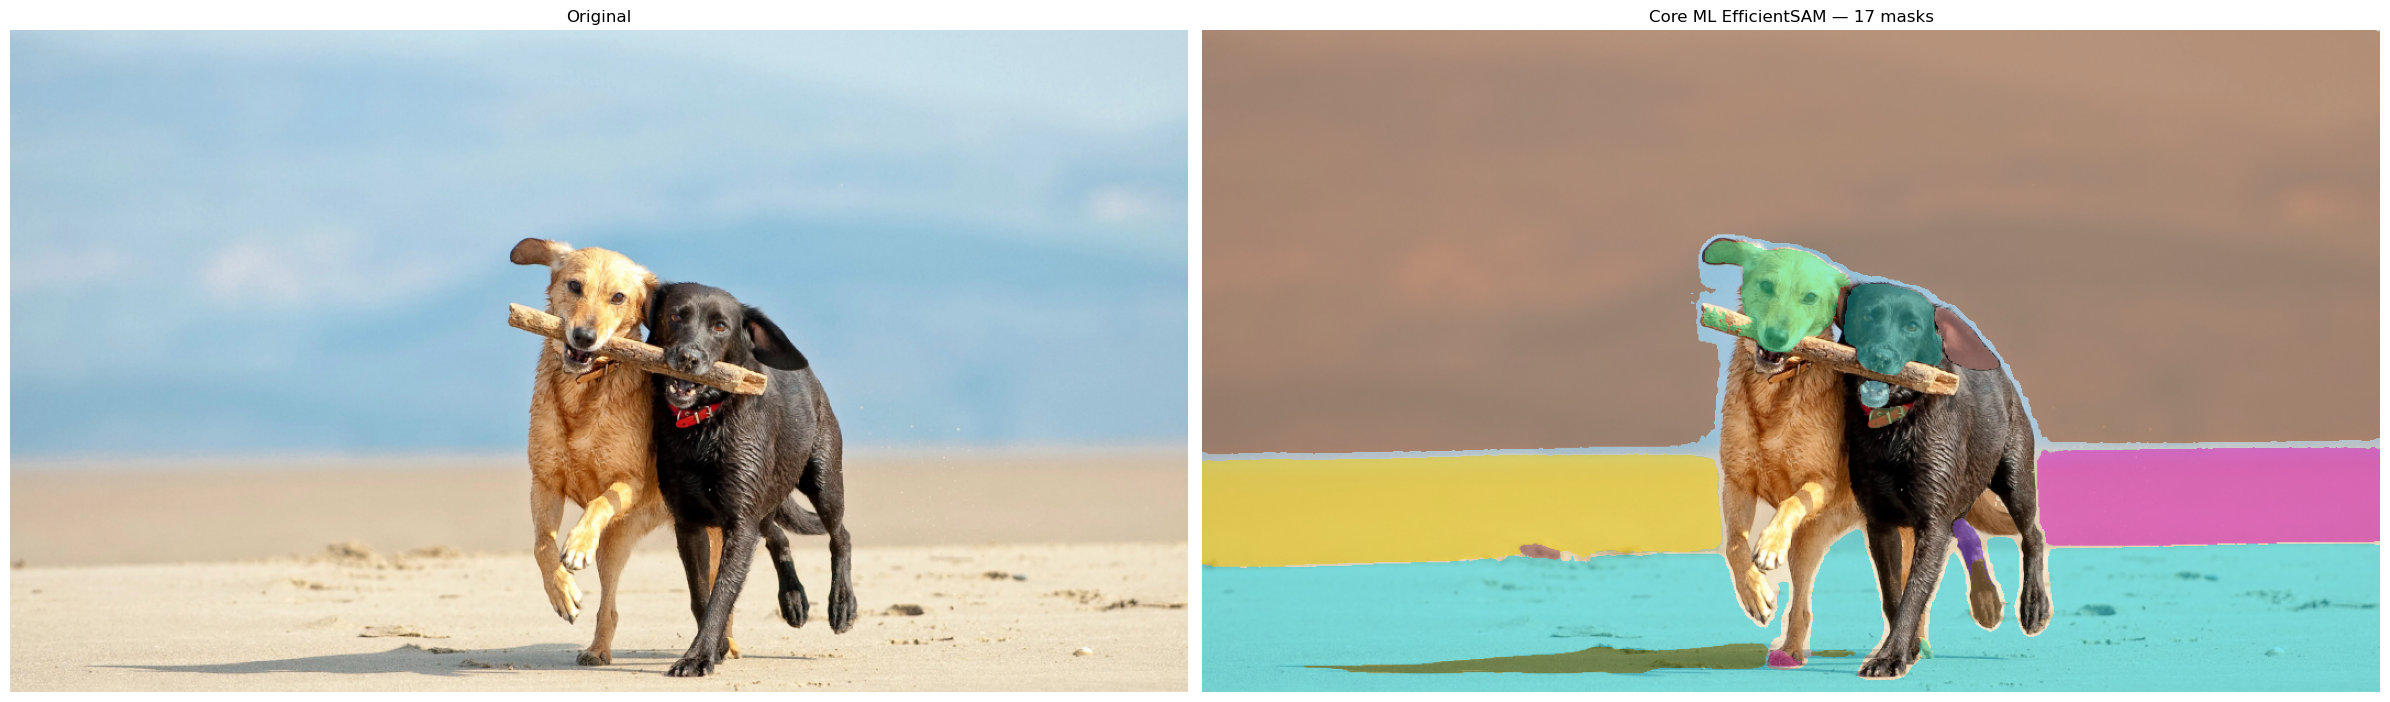

In [18]:
import matplotlib.pyplot as plt

def show_masks(masks, ax):
    ax.set_autoscale_on(False)
    if not masks:
        return
    overlay = np.ones((*masks[0].shape, 4))
    overlay[:, :, 3] = 0
    rng = np.random.default_rng(0)
    for m in sorted(masks, key=lambda x: x.sum(), reverse=True):
        overlay[m] = np.concatenate([rng.random(3), [0.5]])
    ax.imshow(overlay)

fig, ax = plt.subplots(1, 2, figsize=(24, 12))
ax[0].imshow(image_np); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(image_np); show_masks(final_masks, ax[1])
ax[1].set_title(f"Core ML EfficientSAM — {len(final_masks)} masks"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## Memory scaling

The claim to verify: peak memory tracks `DECODER_BATCH`, not `GRID_SIZE`. If that
holds, a 32x32 grid is a runtime cost, not a memory cost — and it fits on a
phone.

The exported decoder has a **static** batch of `DECODER_BATCH`, so the grid sweep
below holds batch fixed and varies only the grid. To see the batch axis you have
to re-export; the theoretical cost is `DECODER_BATCH * 3 * OUTPUT_SIZE^2 * 4 B`,
printed alongside for reference.

In [19]:
import subprocess, textwrap

# Measure in subprocesses — ru_maxrss is a high-water mark that never decreases,
# so sequential in-process runs would each report the max of all prior runs.
probe = textwrap.dedent(f'''
    import os, sys, resource, numpy as np, coremltools as ct
    os.chdir({os.getcwd()!r}); sys.path.insert(0, {os.getcwd()!r})
    grid = int(sys.argv[1])
    batch = {DECODER_BATCH}
    dec = ct.models.MLModel({DECODER_PATH!r})
    embed = np.random.rand(*{EMBED_SHAPE}).astype(np.float32)
    n = grid * grid
    for s in range(0, n, batch):
        dec.predict({{
            "image_embeddings": embed,
            "point_coords": (np.random.rand(1, batch, 1, 2) * {ENCODER_SIZE}).astype(np.float32),
            "point_labels": np.ones((1, batch, 1), np.float32),
        }})
    print(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6)
''')
probe_path = os.path.join(OUT_DIR, "_mem_probe.py")
with open(probe_path, "w") as f:
    f.write(probe)

print(f"decoder static batch = {DECODER_BATCH}")
print(f"{'grid':>6} {'points':>8} {'calls':>7} {'peak RSS':>10}")
for grid in (8, 16, 32):
    out = subprocess.run([sys.executable, probe_path, str(grid)],
                         capture_output=True, text=True)
    lines = out.stdout.strip().splitlines()
    if not lines:
        print(f"{grid:>6} {'probe failed':>8} — {out.stderr.strip().splitlines()[-1:]}")
        continue
    n = grid * grid
    print(f"{grid:>6} {n:>8} {-(-n//DECODER_BATCH):>7} {float(lines[-1]):>7.0f} MB")

logits_mb = DECODER_BATCH * 3 * OUTPUT_SIZE**2 * 4 / 1e6
print(f"\nmask-logit tensor per call: {logits_mb:.1f} MB "
      f"({DECODER_BATCH} x 3 x {OUTPUT_SIZE}^2 x 4 B)")
print("Peak is flat across grid sizes — the grid costs time, not memory.")

decoder static batch = 8
  grid   points   calls   peak RSS
     8       64       8     843 MB
    16      256      32     895 MB
    32     1024     128     918 MB

mask-logit tensor per call: 6.3 MB (8 x 3 x 256^2 x 4 B)
Peak is flat across grid sizes — the grid costs time, not memory.


## Deploying

Both `.mlpackage` bundles drop straight into an Xcode project. The Swift side
mirrors the Python exactly:

```swift
// once per image
let embedding = try encoder.prediction(image: pixelBuffer).image_embeddings

// then per batch of DECODER_BATCH prompts
let out = try decoder.prediction(
    image_embeddings: embedding,
    point_coords: coords,   // 1024-space, shape (1, DECODER_BATCH, 1, 2)
    point_labels: labels
)
```

Things worth knowing before you ship:

- **Interactive tap-to-segment is the strong use case.** Encode once when the
  image loads (~0.85 s), then each tap is one decoder call at ~27 ms. That is
  genuinely real-time. Full segment-everything at grid 32 is a
  "tap button, show progress" feature, not a live one.
- **Point coordinates must be in 1024-space.** Rescaling lives in app code, which
  is what keeps the exported model resolution-agnostic. Passing raw image pixel
  coordinates yields plausible-looking but wrong masks.
- **`DECODER_BATCH` is fixed at export.** Changing it means re-exporting. Pad the
  final partial batch, as the loop above does.
- **Profile compute units on device.** `ComputeUnit.ALL` lets Core ML schedule
  across ANE/GPU/CPU, but the chosen split varies by chip. Compare against
  `.cpuAndNeuralEngine` in Instruments before assuming ANE residency.
- **The timings in this notebook are macOS.** Treat them as a lower bound and
  re-measure on target hardware.